# Iris — the same workflow, through `dolores-lib`

The companion to `../baseline/iris_eda.ipynb`. Identical dataset, identical
result; the difference is how much of it is hand-rolled.

`dolores-lib` here is the **published wheel from TestPyPI**, not a path import.
`uv.lock` pins it to `source = { registry = "https://test.pypi.org/simple/" }`,
so running this notebook is an end-to-end assertion that the release pipeline
actually worked. If the wheel is broken, this fails.

Requires the MLflow server from the repo root: `make mlflow-start`.

In [1]:
import os
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from dolores.data import load_dataset
from dolores.experiment import train
from dolores.inference import load_model, read_manifest
from dolores.tracking import log_run

REPO_ROOT = next(p for p in Path.cwd().parents if (p / ".git").exists())
DATA = REPO_ROOT / "data" / "Iris.csv"
BUNDLE = REPO_ROOT / "data" / "iris-classifier.zip"

# The library never hardcodes a tracking URI; it reads the environment and
# otherwise leaves MLflow's own default alone. Choosing where runs go is
# the caller's job, so the notebook makes that choice explicit.
TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")

print("dolores-lib", version("dolores-lib"))

dolores-lib 0.2.1.dev1+g996352a5b.d20260827


## Load

```python
# baseline
df = pd.read_csv(DATA).drop(columns=["Id"])
```

One call, and the target column travels with the frame from here on. A typo in
`target` or `drop` raises instead of silently fitting on an identifier.

In [2]:
ds = load_dataset(DATA, target="Species", drop=["Id"])

print(len(ds), "rows |", ds.features)
ds.frame.head()

150 rows | ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Explore

Raw pandas and seaborn from here to the end of this section, deliberately.
Exploration is one-off and dataset-specific; `dolores-lib` is dataset-agnostic
and has no business knowing that `Species` is categorical and worth colouring by.

The library's remit starts where the work becomes repeatable and *shipped*:
load, split, train, score, save, serve.

In [3]:
display(ds.y.value_counts())
ds.X.describe()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


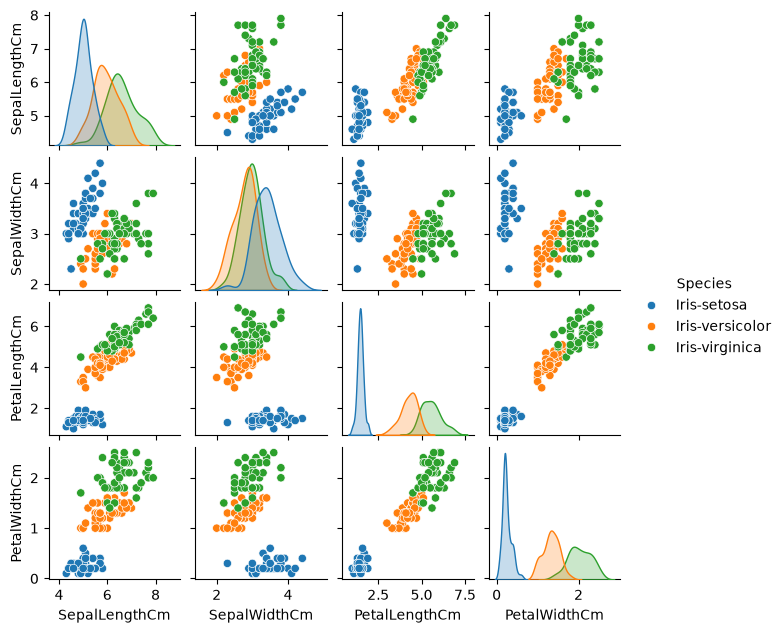

In [4]:
sns.pairplot(ds.frame, hue=ds.target, height=1.6)
plt.show()

Petal length and width separate the classes almost completely; the sepal
features overlap between versicolor and virginica. A linear model should do.

## Split

```python
# baseline
X = df.drop(columns=["Species"])
y = df["Species"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

Four variables become two datasets. Stratification is on by default and the
row index is preserved, so a prediction can be traced back to its row.

In [5]:
train_ds, test_ds = ds.split(test_size=0.2, seed=42)

print(len(train_ds), "/", len(test_ds))
test_ds.y.value_counts()

120 / 30


Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64

## Train

The baseline spends 25 lines here: a loop that fits, predicts, calls four
separate sklearn metric functions, builds a confusion-matrix figure, and makes
six `mlflow.*` calls by hand.

`train` fits on the training split and scores on the held-out one — the split is
not a parameter you can get wrong. `log_run` ships one result as one MLflow run.
Choosing the estimators is still the caller's job: the library holds no list of
blessed models.

In [6]:
candidates = {
    "logreg": LogisticRegression(max_iter=200),
    "rf": RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42),
    "gb": GradientBoostingClassifier(n_estimators=50, max_depth=2, random_state=42),
}

results = [train(est, train_ds, test_ds, name=n) for n, est in candidates.items()]

pd.DataFrame({r.name: r.metrics.scalars() for r in results}).T.sort_values(
    "f1", ascending=False
)

,accuracy,precision,recall,f1
logreg,0.966667,0.969697,0.966667,0.966583
rf,0.966667,0.969697,0.966667,0.966583
gb,0.933333,0.933333,0.933333,0.933333


## Select and serialize

```python
# baseline
joblib.dump(best_model, MODEL_PATH)
```

The bundle is a zip: the fitted estimator plus a manifest describing the
features, their order, their dtypes, the classes, and the runtime it was trained
under. A bare pickle carries none of that, which is why the baseline's
"simulate the server" cell has to get the column order right by hand and nothing
checks it.

In [7]:
best = max(results, key=lambda r: r.metrics.f1)
bundle = best.save_bundle(BUNDLE)

print(best.name, "->", bundle.name)
pd.DataFrame(
    best.metrics.confusion_matrix,
    index=best.metrics.labels,
    columns=best.metrics.labels,
)

logreg -> iris-classifier.zip


,Iris-setosa,Iris-versicolor,Iris-virginica
Iris-setosa,10,0,0
Iris-versicolor,0,9,1
Iris-virginica,0,0,10


Now log every candidate to MLflow. The winner also carries the bundle as its
artifact and is tagged with the manifest's `model_id`, which is the link between
a run and the exact bytes the inference server will load.

Note the library logs the **bundle**, not `mlflow.sklearn.log_model` — one
serialization path, not two competing ones.

In [8]:
for r in results:
    run_id = log_run(
        r,
        experiment="iris-consumer",
        bundle=bundle if r is best else None,
        tracking_uri=TRACKING_URI,
    )
    print(f"{r.name:8} run={run_id}")

🏃 View run logreg at: http://127.0.0.1:5000/#/experiments/2/runs/ea913631e116477184ce562a9edcd84e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
logreg   run=ea913631e116477184ce562a9edcd84e


🏃 View run rf at: http://127.0.0.1:5000/#/experiments/2/runs/db01c071e3f44c34815c3eb7a106628e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
rf       run=db01c071e3f44c34815c3eb7a106628e


🏃 View run gb at: http://127.0.0.1:5000/#/experiments/2/runs/7b6400bd760a49a4b2c81bf21158eef1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
gb       run=7b6400bd760a49a4b2c81bf21158eef1


Per-class detail lives on the same object, and persists as structured JSON
for anything downstream that wants it.

In [9]:
best.metrics.write_json(REPO_ROOT / "data" / "metrics.json")
pd.DataFrame(best.metrics.report).T

,precision,recall,f1-score,support
Iris-setosa,1.000000,1.000000,1.000000,10.0
Iris-versicolor,1.000000,0.900000,0.947368,10.0
Iris-virginica,0.909091,1.000000,0.952381,10.0
macro avg,0.969697,0.966667,0.966583,30.0
weighted avg,0.969697,0.966667,0.966583,30.0


## What the server does

The API's entire import from this library is `load_model`. It never talks to
MLflow. First, read the manifest — note that **no unpickling happens here**,
which is what lets the server reject an incompatible bundle before executing
any of its bytes.

In [10]:
read_manifest(bundle).to_dict()

{'format_version': 1,
 'model_id': 'logisticregression-20260827T213616Z-689972',
 'created_at': '2026-08-27T21:36:16.859850+00:00',
 'estimator': 'sklearn.linear_model._logistic.LogisticRegression',
 'features': [{'name': 'SepalLengthCm', 'dtype': 'float64'},
  {'name': 'SepalWidthCm', 'dtype': 'float64'},
  {'name': 'PetalLengthCm', 'dtype': 'float64'},
  {'name': 'PetalWidthCm', 'dtype': 'float64'}],
 'target': {'name': 'Species',
  'classes': ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']},
 'runtime': {'python': '3.12.13',
  'scikit-learn': '1.9.0',
  'numpy': '2.5.2',
  'dolores-lib': '0.2.1.dev1+g996352a5b.d20260827'},
 'metrics': {'accuracy': 0.9666666666666667,
  'precision': 0.9696969696969697,
  'recall': 0.9666666666666667,
  'f1': 0.9665831244778612}}

In [11]:
model = load_model(bundle)

model.predict({
    "PetalWidthCm": 1.5,
    "SepalLengthCm": 6.3,
    "PetalLengthCm": 5.1,
    "SepalWidthCm": 2.8,
})

Prediction(label='Iris-virginica', confidence=0.526131057953747)

Field order in the payload is irrelevant — the manifest defines the canonical
order and `predict` reorders. What is not irrelevant is the schema:

In [12]:
for bad in [
    {"SepalLengthCm": 6.3, "SepalWidthCm": 2.8, "PetalLength": 5.1, "PetalWidthCm": 1.5},
    {"SepalLengthCm": "wide", "SepalWidthCm": 2.8, "PetalLengthCm": 5.1, "PetalWidthCm": 1.5},
]:
    try:
        model.predict(bad)
    except Exception as exc:
        print(f"{type(exc).__name__}: {exc}")

FeatureValidationError: payload does not match the model's schema: missing ['PetalLengthCm']; unexpected ['PetalLength']
FeatureValidationError: feature 'SepalLengthCm' cannot be read as float64: 'wide'


Those errors are what the API returns as a 422 instead of a silently wrong
prediction.

The manifest guarantees **structure** — names, order, dtypes, classes. It
guarantees nothing **semantic**: it cannot tell millimetres from centimetres.
Nothing at the serving boundary can, and that is a data-quality and monitoring
concern, explicitly out of scope here rather than quietly assumed.